<a href="https://colab.research.google.com/github/Lexi-Zhou/stats201-project-zzz/blob/main/Code/W5_2_LOR_diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Load data

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Define LOR function: Weighted Log Odds Ratio

In [ ]:
def compute_log_odds_zscore(
    group1_counts,
    group2_counts,
    prior_counts,
    prior_type="background",   # "background" or "flat"
    alpha=0.01                 # prior strength
):
    """
    calculate z-score with configurable Dirichlet prior

    prior_type:
      - "background": alpha_w ∝ background corpus frequency
      - "flat": alpha_w = constant alpha for all words
    """

    n1 = sum(group1_counts.values())
    n2 = sum(group2_counts.values())

    vocab = set(group1_counts.keys()) | set(group2_counts.keys())
    z_scores = {}

    if prior_type == "background":
        alpha0 = sum(prior_counts.values())
    else:  # flat prior
        alpha0 = alpha * len(vocab)

    for word in vocab:
        if prior_type == "background":
            alpha_w = prior_counts.get(word, 0) + alpha
        else:
            alpha_w = alpha

        log_odds = (
            np.log((group1_counts[word] + alpha_w) /
                   (n1 + alpha0 - group1_counts[word] - alpha_w)) -
            np.log((group2_counts[word] + alpha_w) /
                   (n2 + alpha0 - group2_counts[word] - alpha_w))
        )

        variance = 1 / (group1_counts[word] + alpha_w) + \
                   1 / (group2_counts[word] + alpha_w)

        z_scores[word] = log_odds / np.sqrt(variance)

    return z_scores

# 3. N-gram counter

In [ ]:
def get_ngram_counts(series, ngram_range=(1,2)):
    counter = Counter()

    for text in series.astype(str):
        tokens = text.split()
        L = len(tokens)

        for n in range(ngram_range[0], ngram_range[1] + 1):
            if L < n:
                continue
            for i in range(L - n + 1):
                gram = " ".join(tokens[i:i+n])
                counter[gram] += 1

    return counter

# 4. Loop and process each df

## 4.1 prepare df

In [ ]:
file_dict = {
    "STEM_Poor": "18_RMP_stem_poor.csv",
    "STEM_Avg": "18_RMP_stem_average.csv",
    "STEM_Good": "18_RMP_stem_good.csv",
    "Human_Poor": "18_RMP_humanities_poor.csv",
    "Human_Avg": "18_RMP_humanities_average.csv",
    "Human_Good": "18_RMP_humanities_good.csv"
}
base_path = "/content/drive/MyDrive/Colab Notebooks/stats201_final_project/Week_4/"

## 4.2 top words lists

In [ ]:
print("--- Top 20 Lists (unigram) ---")

all_formatted_outputs_str = [] # Initialize list to store formatted outputs
all_z_scores = [] # Initialize list to store Z-score dataframes for heatmaps

for label, filename in file_dict.items():
  df_raw = pd.read_csv(base_path + filename)

  for text_col in ['comments_scrubbed']:

    # word frequency
    female_series = df_raw[df_raw['prof_gender_finalized'] == 'female'][text_col]
    male_series = df_raw[df_raw['prof_gender_finalized'] == 'male'][text_col]

    NGRAM_RANGE = (1, 1)
    female_counts = get_ngram_counts(female_series, ngram_range=NGRAM_RANGE)
    male_counts = get_ngram_counts(male_series, ngram_range=NGRAM_RANGE)
    background_counts = female_counts + male_counts

    # z-scores
    z_scores = compute_log_odds_zscore(male_counts, female_counts, background_counts)

    # => dataframe
    res_df = pd.DataFrame(list(z_scores.items()), columns = ['Word', 'Z_Score'])

    # Add directional label
    res_df['Direction'] = res_df['Z_Score'].apply(lambda x: 'Female' if x < 0 else 'Male')

    # rank by effect size (Abs_Z)
    res_df['Abs_Z'] = res_df['Z_Score'].abs()

    # Top 20 words by effect size
    top_20 = res_df.sort_values(by='Abs_Z', ascending=False).head(20)

    # Prepare output for display and collection as requested by the user
    output_to_display = top_20[['Word', 'Z_Score', 'Direction']].reset_index(drop=True)

    current_output_buffer = []
    current_output_buffer.append(f"\n{'='*30}")
    current_output_buffer.append(f"SUBSET: {label}")
    current_output_buffer.append(f"COLUMN: {text_col}")
    current_output_buffer.append(f"{'='*30}")
    current_output_buffer.append(output_to_display.to_string(index=False))
    current_output_buffer_str = "\n".join(current_output_buffer)

    print(current_output_buffer_str) # Output to the text box
    all_formatted_outputs_str.append(current_output_buffer_str) # Collect for saving


    res_df_full = res_df[['Word', 'Z_Score']].set_index('Word')
    res_df_full.columns = [f"{label}_{text_col}"]
    all_z_scores.append(res_df_full)

--- Top 20 Lists (unigram) ---

SUBSET: STEM_Poor
COLUMN: comments_scrubbed
       Word   Z_Score Direction
     carson -2.187723    Female
   clinical -2.187723    Female
        lab  2.172084      Male
  chemistry  1.980510      Male
 recitation -1.974929    Female
    narcisa -1.865317    Female
         su  1.768405      Male
        not -1.768119    Female
     claire -1.744703    Female
        way -1.731438    Female
       time -1.671152    Female
unorganized -1.657071    Female
   computer  1.636993      Male
      early -1.615131    Female
      smart  1.598728      Male
  professor  1.593325      Male
       have -1.591786    Female
     review -1.578803    Female
      funny  1.546962      Male
       idea  1.542612      Male

SUBSET: STEM_Avg
COLUMN: comments_scrubbed
       Word   Z_Score Direction
   clinical -2.433345    Female
      nurse -2.414563    Female
      funny  2.094689      Male
   homework  2.023190      Male
 instructor -1.940496    Female
   calculus  1.8

## 4.3 heatmap

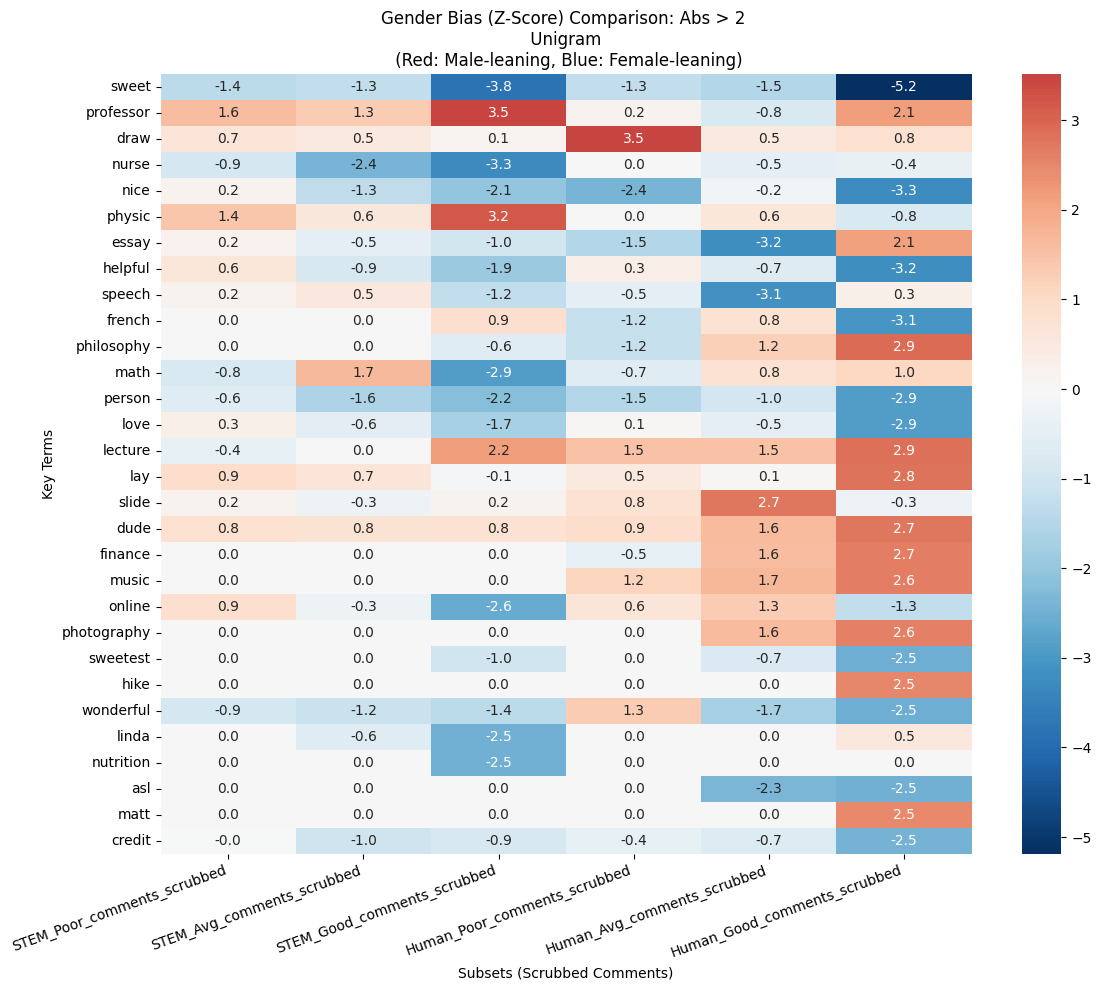

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

combined_df = pd.concat(all_z_scores, axis=1).fillna(0)

# Filter combined_df to only include 'comments_scrubbed' columns
scrubbed_cols = [col for col in combined_df.columns if 'comments_scrubbed' in col]
combined_df_scrubbed = combined_df[scrubbed_cols]

# Determine interesting words based on Z-scores in scrubbed comments
# Filter for words where Abs(Z) > 2 in at least one scrubbed column,
# then select the top 30 by largest max Abs(Z)
interesting_words_scrubbed = combined_df_scrubbed.loc[combined_df_scrubbed.abs().max(axis=1) > 2].abs().max(axis=1).nlargest(30).index

# Prepare heatmap data for these significant words in scrubbed comments
heatmap_data_scrubbed = combined_df_scrubbed.loc[interesting_words_scrubbed]

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data_scrubbed, cmap="RdBu_r", center=0, annot=True, fmt=".1f")
plt.title("Gender Bias (Z-Score) Comparison: Abs > 2 \n Unigram \n (Red: Male-leaning, Blue: Female-leaning)")
plt.xlabel("Subsets (Scrubbed Comments)")
plt.ylabel("Key Terms")
plt.xticks(rotation=20, ha='right') # Rotate column labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## 4.4 frequency-weight plot

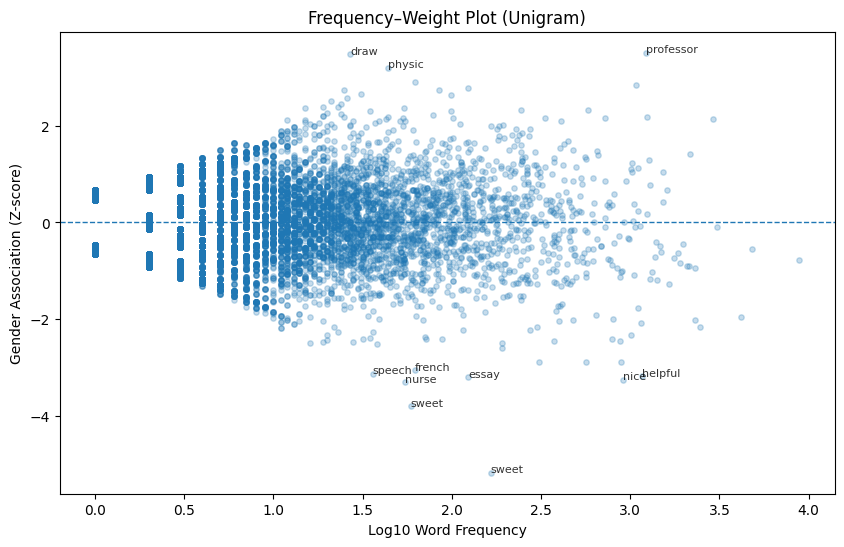

In [ ]:
plot_dfs = []

for label, filename in file_dict.items():
    df_raw = pd.read_csv(base_path + filename)

    female_series = df_raw[df_raw['prof_gender_finalized'] == 'female']['comments_scrubbed']
    male_series = df_raw[df_raw['prof_gender_finalized'] == 'male']['comments_scrubbed']

    NGRAM_RANGE = (1, 1)
    female_counts = get_ngram_counts(female_series, ngram_range=NGRAM_RANGE)
    male_counts = get_ngram_counts(male_series, ngram_range=NGRAM_RANGE)
    background_counts = female_counts + male_counts

    z_scores = compute_log_odds_zscore(male_counts, female_counts, background_counts)

    rows = []
    for word, z in z_scores.items():
        freq = female_counts[word] + male_counts[word]
        if freq == 0:
            continue
        rows.append({
            "Word": word,
            "Z_Score": z,
            "Frequency": freq,
            "Log_Freq": np.log10(freq),
            "Subset": label
        })

    plot_dfs.append(pd.DataFrame(rows))

plot_df_uni = pd.concat(plot_dfs, ignore_index=True)

# plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df_uni["Log_Freq"],
    plot_df_uni["Z_Score"],
    alpha=0.25,
    s=15
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Log10 Word Frequency")
plt.ylabel("Gender Association (Z-score)")
plt.title("Frequency–Weight Plot (Unigram)")

# annotate extreme words
annot_df = plot_df_uni[
    (plot_df_uni["Frequency"] >= 20) &
    (plot_df_uni["Z_Score"].abs() >= 3)
]



for _, row in annot_df.iterrows():
    plt.text(
        row["Log_Freq"],
        row["Z_Score"],
        row["Word"],
        fontsize=8,
        alpha=0.8
    )

plt.show()


# 5. N-gram extension (unigram + bigram)

## 5.1 top words lists

In [ ]:
print("--- Top 20 Lists (unigram + bigram) ---")

all_formatted_outputs_str_ngram = [] # Initialize list to store formatted outputs
all_z_scores_ngram = [] # Initialize list to store Z-score dataframes for heatmaps

for label, filename in file_dict.items():
  df_raw = pd.read_csv(base_path + filename)

  for text_col in ['comments_scrubbed']:

    # word frequency
    female_series = df_raw[df_raw['prof_gender_finalized'] == 'female'][text_col]
    male_series = df_raw[df_raw['prof_gender_finalized'] == 'male'][text_col]

    NGRAM_RANGE = (1, 2)
    female_counts = get_ngram_counts(female_series, ngram_range=NGRAM_RANGE)
    male_counts = get_ngram_counts(male_series, ngram_range=NGRAM_RANGE)
    background_counts = female_counts + male_counts

    # z-scores
    z_scores = compute_log_odds_zscore(male_counts, female_counts, background_counts)

    # => dataframe
    res_df = pd.DataFrame(list(z_scores.items()), columns = ['Word', 'Z_Score'])

    # Add directional label
    res_df['Direction'] = res_df['Z_Score'].apply(lambda x: 'Female' if x < 0 else 'Male')

    # rank by effect size (Abs_Z)
    res_df['Abs_Z'] = res_df['Z_Score'].abs()

    # Top 20 words by effect size
    top_20 = res_df.sort_values(by='Abs_Z', ascending=False).head(20)

    # Prepare output for display and collection as requested by the user
    output_to_display = top_20[['Word', 'Z_Score', 'Direction']].reset_index(drop=True)

    current_output_buffer = []
    current_output_buffer.append(f"\n{'='*30}")
    current_output_buffer.append(f"SUBSET: {label}")
    current_output_buffer.append(f"COLUMN: {text_col}")
    current_output_buffer.append(f"{'='*30}")
    current_output_buffer.append(output_to_display.to_string(index=False))
    current_output_buffer_str = "\n".join(current_output_buffer)

    print(current_output_buffer_str) # Output to the text box
    all_formatted_outputs_str_ngram.append(current_output_buffer_str) # Collect for saving


    res_df_full = res_df[['Word', 'Z_Score']].set_index('Word')
    res_df_full.columns = [f"{label}_{text_col}"]
    all_z_scores_ngram.append(res_df_full)

--- Top 20 Lists (unigram + bigram) ---

SUBSET: STEM_Poor
COLUMN: comments_scrubbed
           Word   Z_Score Direction
       clinical -2.187167    Female
         carson -2.187167    Female
            lab  2.167293      Male
      dr carson -2.085296    Female
      chemistry  1.979607      Male
     recitation -1.974373    Female
  read directly -1.864965    Female
        narcisa -1.864965    Female
   help student -1.862890    Female
             su  1.767905      Male
         claire -1.744412    Female
            way -1.728740    Female
            not -1.722297    Female
          dr su  1.703516      Male
           time -1.664439    Female
    unorganized -1.656401    Female
       computer  1.636601      Male
easy understand -1.614897    Female
          early -1.614897    Female
      test make -1.614897    Female

SUBSET: STEM_Avg
COLUMN: comments_scrubbed
         Word   Z_Score Direction
     clinical -2.431878    Female
        nurse -2.412447    Female
        funny

## 5.2 heatmap

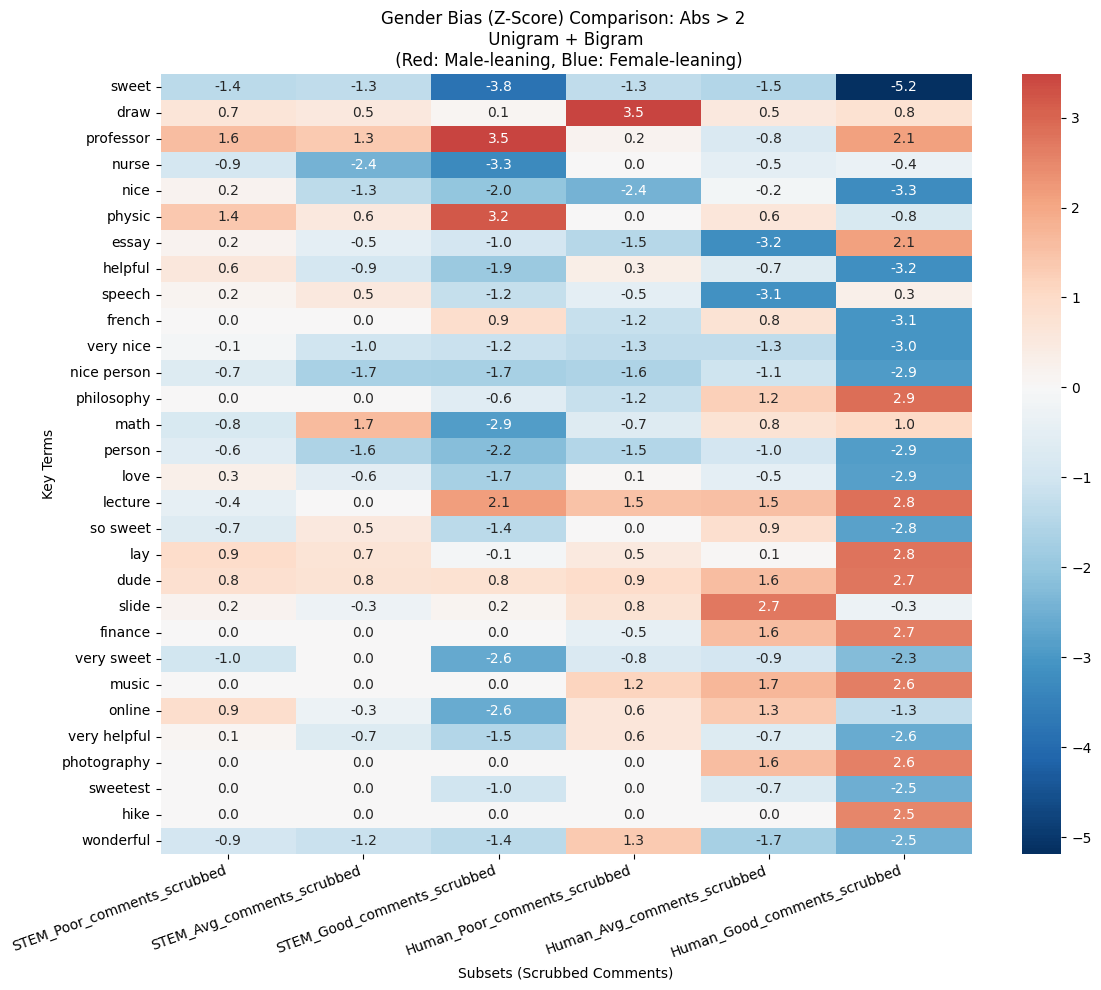

In [ ]:
combined_df = pd.concat(all_z_scores_ngram, axis=1).fillna(0)

# Filter combined_df to only include 'comments_scrubbed' columns
scrubbed_cols = [col for col in combined_df.columns if 'comments_scrubbed' in col]
combined_df_scrubbed = combined_df[scrubbed_cols]

# Determine interesting words based on Z-scores in scrubbed comments
# Filter for words where Abs(Z) > 2 in at least one scrubbed column,
# then select the top 30 by largest max Abs(Z)
interesting_words_scrubbed = combined_df_scrubbed.loc[combined_df_scrubbed.abs().max(axis=1) > 2].abs().max(axis=1).nlargest(30).index

# Prepare heatmap data for these significant words in scrubbed comments
heatmap_data_scrubbed = combined_df_scrubbed.loc[interesting_words_scrubbed]

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data_scrubbed, cmap="RdBu_r", center=0, annot=True, fmt=".1f")
plt.title("Gender Bias (Z-Score) Comparison: Abs > 2 \n Unigram + Bigram \n (Red: Male-leaning, Blue: Female-leaning)")
plt.xlabel("Subsets (Scrubbed Comments)")
plt.ylabel("Key Terms")
plt.xticks(rotation=20, ha='right') # Rotate column labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## 5.3 frequency-weight plot

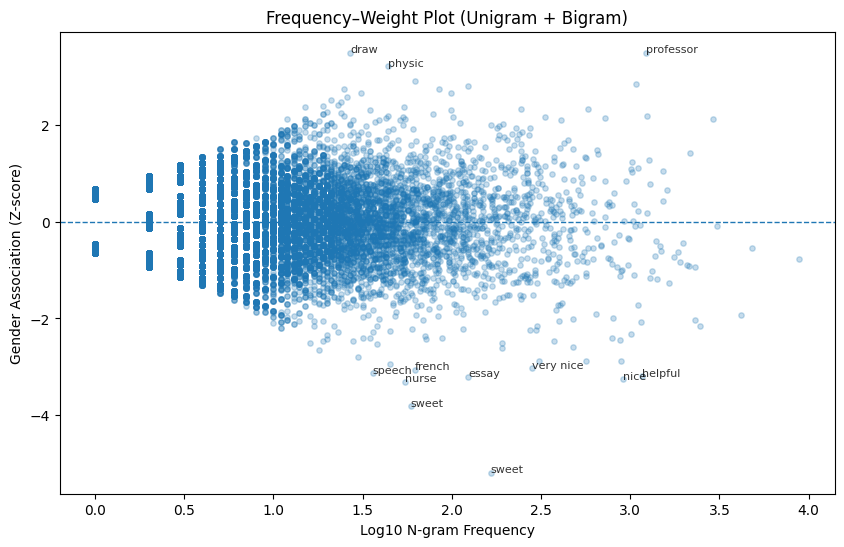

In [ ]:
plot_dfs = []

for label, filename in file_dict.items():
    df_raw = pd.read_csv(base_path + filename)

    female_series = df_raw[df_raw['prof_gender_finalized'] == 'female']['comments_scrubbed']
    male_series = df_raw[df_raw['prof_gender_finalized'] == 'male']['comments_scrubbed']

    # unigram + bigram
    NGRAM_RANGE = (1, 2)
    female_counts = get_ngram_counts(female_series, ngram_range=NGRAM_RANGE)
    male_counts = get_ngram_counts(male_series, ngram_range=NGRAM_RANGE)
    background_counts = female_counts + male_counts

    z_scores = compute_log_odds_zscore(male_counts, female_counts, background_counts)

    rows = []
    for word, z in z_scores.items():
        freq = female_counts[word] + male_counts[word]
        if freq == 0:
            continue
        rows.append({
            "Word": word,
            "Z_Score": z,
            "Frequency": freq,
            "Log_Freq": np.log10(freq),
            "Subset": label
        })

    plot_dfs.append(pd.DataFrame(rows))

plot_df_ngram = pd.concat(plot_dfs, ignore_index=True)

# plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df_ngram["Log_Freq"],
    plot_df_ngram["Z_Score"],
    alpha=0.25,
    s=15
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Log10 N-gram Frequency")
plt.ylabel("Gender Association (Z-score)")
plt.title("Frequency–Weight Plot (Unigram + Bigram)")

# annotate extreme ngrams
annot_df = plot_df_ngram[
    (plot_df_ngram["Frequency"] >= 20) &
    (plot_df_ngram["Z_Score"].abs() >= 3)
]

for _, row in annot_df.iterrows():
    plt.text(
        row["Log_Freq"],
        row["Z_Score"],
        row["Word"],
        fontsize=8,
        alpha=0.8
    )

plt.show()


# 6. NEG_ prefix
Use columns with negation marked + unigram

## 6.1 top words lists

In [ ]:
print("--- Top 20 Lists (unigram + NEG_) ---")

all_formatted_outputs_str_neg = [] # Initialize list to store formatted outputs
all_z_scores_neg = [] # Initialize list to store Z-score dataframes for heatmaps

for label, filename in file_dict.items():
  df_raw = pd.read_csv(base_path + filename)

  for text_col in ['comments_scrubbed_neg']:

    # word frequency
    female_series = df_raw[df_raw['prof_gender_finalized'] == 'female'][text_col]
    male_series = df_raw[df_raw['prof_gender_finalized'] == 'male'][text_col]

    NGRAM_RANGE = (1, 1)
    female_counts = get_ngram_counts(female_series, ngram_range=NGRAM_RANGE)
    male_counts = get_ngram_counts(male_series, ngram_range=NGRAM_RANGE)
    background_counts = female_counts + male_counts

    # z-scores
    z_scores = compute_log_odds_zscore(male_counts, female_counts, background_counts)

    # => dataframe
    res_df = pd.DataFrame(list(z_scores.items()), columns = ['Word', 'Z_Score'])

    # Add directional label
    res_df['Direction'] = res_df['Z_Score'].apply(lambda x: 'Female' if x < 0 else 'Male')

    # rank by effect size (Abs_Z)
    res_df['Abs_Z'] = res_df['Z_Score'].abs()

    # Top 20 words by effect size
    top_20 = res_df.sort_values(by='Abs_Z', ascending=False).head(20)

    # Prepare output for display and collection as requested by the user
    output_to_display = top_20[['Word', 'Z_Score', 'Direction']].reset_index(drop=True)

    current_output_buffer = []
    current_output_buffer.append(f"\n{'='*30}")
    current_output_buffer.append(f"SUBSET: {label}")
    current_output_buffer.append(f"COLUMN: {text_col}")
    current_output_buffer.append(f"{'='*30}")
    current_output_buffer.append(output_to_display.to_string(index=False))
    current_output_buffer_str = "\n".join(current_output_buffer)

    print(current_output_buffer_str) # Output to the text box
    all_formatted_outputs_str_neg.append(current_output_buffer_str) # Collect for saving


    res_df_full = res_df[['Word', 'Z_Score']].set_index('Word')
    res_df_full.columns = [f"{label}_{text_col}"]
    all_z_scores_neg.append(res_df_full)

--- Top 20 Lists (unigram + NEG_) ---

SUBSET: STEM_Poor
COLUMN: comments_scrubbed_neg
       Word   Z_Score Direction
        lab  2.408662      Male
     carson -2.187723    Female
   clinical -2.187723    Female
 recitation -1.974929    Female
  chemistry  1.923771      Male
    narcisa -1.865317    Female
        not -1.785330    Female
       time -1.781099    Female
         su  1.768405      Male
        way -1.737394    Female
       good  1.692974      Male
unorganized -1.657071    Female
      right  1.653168      Male
  professor  1.618067      Male
      early -1.615131    Female
     claire -1.615131    Female
    concept -1.578803    Female
   computer  1.567179      Male
      funny  1.546962      Male
 instructor -1.546834    Female

SUBSET: STEM_Avg
COLUMN: comments_scrubbed_neg
       Word   Z_Score Direction
      nurse -2.414563    Female
   clinical -2.203433    Female
      funny  2.039226      Male
   homework  1.985200      Male
   calculus  1.894246      Male
 

## 6.2 heatmap

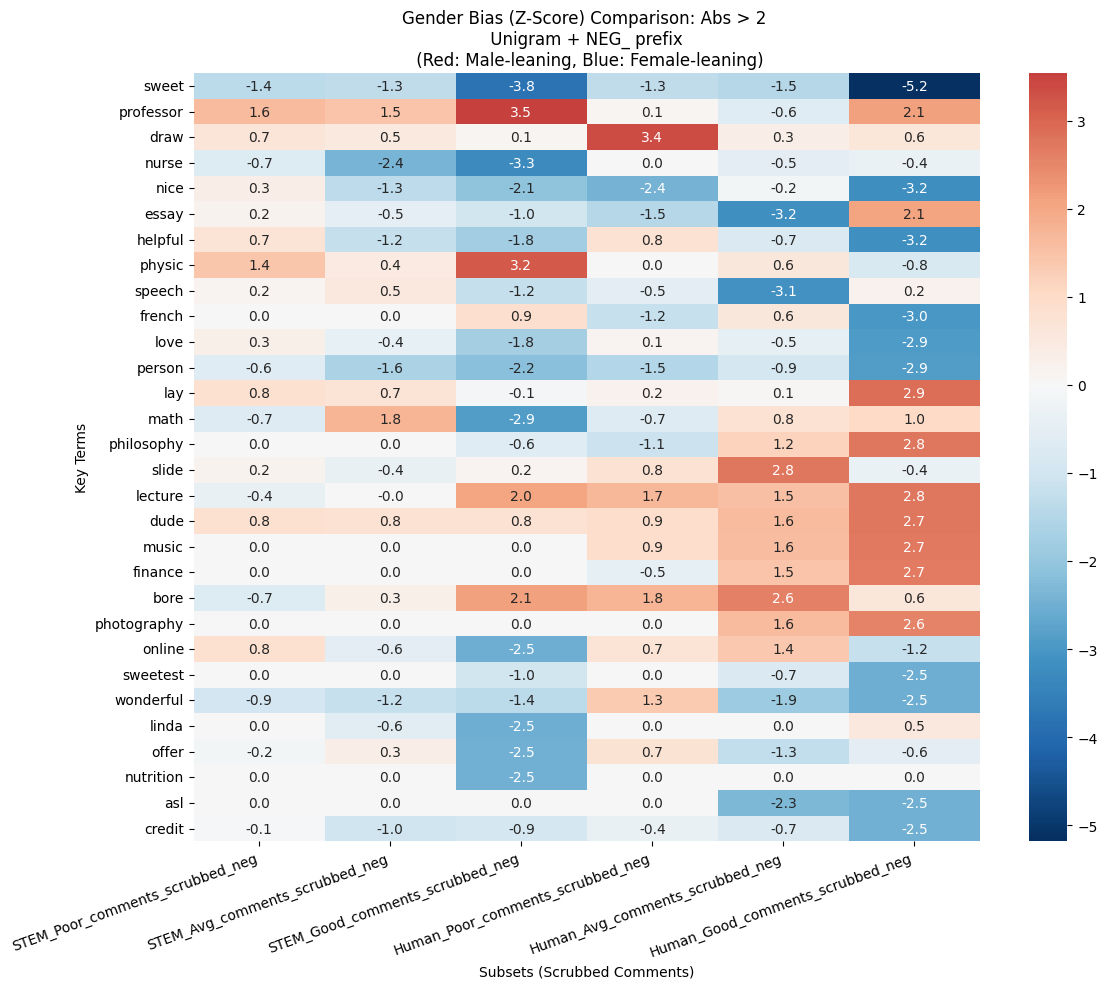

In [ ]:
combined_df = pd.concat(all_z_scores_neg, axis=1).fillna(0)

# Filter combined_df to only include 'comments_scrubbed' columns
scrubbed_cols = [col for col in combined_df.columns if 'comments_scrubbed' in col]
combined_df_scrubbed = combined_df[scrubbed_cols]

# Determine interesting words based on Z-scores in scrubbed comments
# Filter for words where Abs(Z) > 2 in at least one scrubbed column,
# then select the top 30 by largest max Abs(Z)
interesting_words_scrubbed = combined_df_scrubbed.loc[combined_df_scrubbed.abs().max(axis=1) > 2].abs().max(axis=1).nlargest(30).index

# Prepare heatmap data for these significant words in scrubbed comments
heatmap_data_scrubbed = combined_df_scrubbed.loc[interesting_words_scrubbed]

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data_scrubbed, cmap="RdBu_r", center=0, annot=True, fmt=".1f")
plt.title("Gender Bias (Z-Score) Comparison: Abs > 2 \n Unigram + NEG_ prefix \n (Red: Male-leaning, Blue: Female-leaning)")
plt.xlabel("Subsets (Scrubbed Comments)")
plt.ylabel("Key Terms")
plt.xticks(rotation=20, ha='right') # Rotate column labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

## 6.3 frequency-weight plot

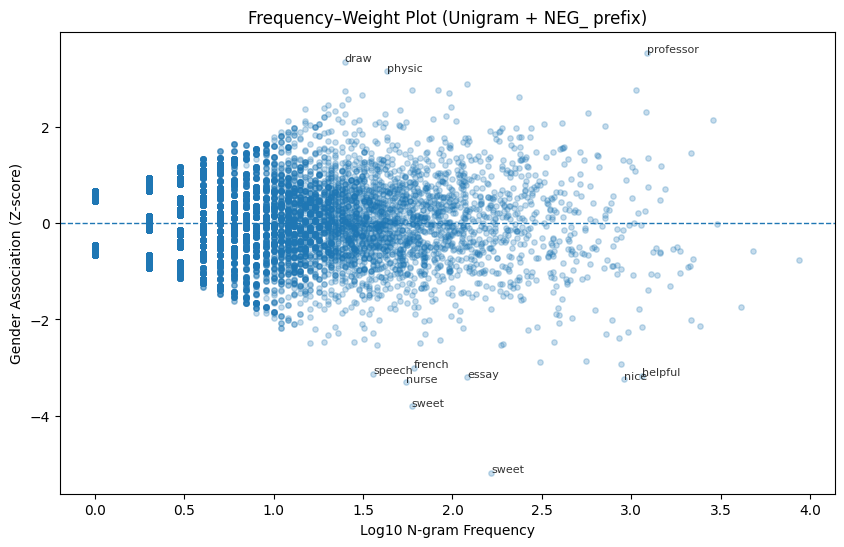

In [ ]:
plot_dfs = []

for label, filename in file_dict.items():
    df_raw = pd.read_csv(base_path + filename)

    female_series = df_raw[df_raw['prof_gender_finalized'] == 'female']['comments_scrubbed_neg']
    male_series = df_raw[df_raw['prof_gender_finalized'] == 'male']['comments_scrubbed_neg']

    NGRAM_RANGE = (1, 1)
    female_counts = get_ngram_counts(female_series, ngram_range=NGRAM_RANGE)
    male_counts = get_ngram_counts(male_series, ngram_range=NGRAM_RANGE)
    background_counts = female_counts + male_counts

    z_scores = compute_log_odds_zscore(male_counts, female_counts, background_counts)

    rows = []
    for word, z in z_scores.items():
        freq = female_counts[word] + male_counts[word]
        if freq == 0:
            continue
        rows.append({
            "Word": word,
            "Z_Score": z,
            "Frequency": freq,
            "Log_Freq": np.log10(freq),
            "Subset": label
        })

    plot_dfs.append(pd.DataFrame(rows))

plot_df_ngram = pd.concat(plot_dfs, ignore_index=True)

# plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_df_ngram["Log_Freq"],
    plot_df_ngram["Z_Score"],
    alpha=0.25,
    s=15
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Log10 N-gram Frequency")
plt.ylabel("Gender Association (Z-score)")
plt.title("Frequency–Weight Plot (Unigram + NEG_ prefix)")

# annotate extreme ngrams
annot_df = plot_df_ngram[
    (plot_df_ngram["Frequency"] >= 20) &
    (plot_df_ngram["Z_Score"].abs() >= 3)
]

for _, row in annot_df.iterrows():
    plt.text(
        row["Log_Freq"],
        row["Z_Score"],
        row["Word"],
        fontsize=8,
        alpha=0.8
    )

plt.show()

# 7. Prior sensitivity check


In [ ]:
# select a subset
SENSITIVITY_SUBSET = "Human_Good"
NGRAM_RANGE = (1, 1)
TOP_K = 20

In [ ]:
# different prior configurations
prior_settings = [
    {"name": "Flat_Alpha_0.01", "prior_type": "flat", "alpha": 0.01},
    {"name": "Flat_Alpha_0.1",  "prior_type": "flat", "alpha": 0.1},
    {"name": "Background_0.01","prior_type": "background", "alpha": 0.01},
]

In [ ]:
# check prior sensitivity
filename = file_dict[SENSITIVITY_SUBSET]
df_raw = pd.read_csv(base_path + filename)

female_series = df_raw[df_raw['prof_gender_finalized'] == 'female']['comments_scrubbed']
male_series = df_raw[df_raw['prof_gender_finalized'] == 'male']['comments_scrubbed']

female_counts = get_ngram_counts(female_series, ngram_range=NGRAM_RANGE)
male_counts = get_ngram_counts(male_series, ngram_range=NGRAM_RANGE)
background_counts = female_counts + male_counts

top_words_by_prior = {}

for setting in prior_settings:
    z_scores = compute_log_odds_zscore(
        male_counts,
        female_counts,
        background_counts,
        prior_type=setting["prior_type"],
        alpha=setting["alpha"]
    )

    res_df = pd.DataFrame(
        list(z_scores.items()),
        columns=["Word", "Z_Score"]
    )
    res_df["Abs_Z"] = res_df["Z_Score"].abs()

    top_k_words = (
        res_df.sort_values("Abs_Z", ascending=False)
              .head(TOP_K)["Word"]
              .tolist()
    )

    top_words_by_prior[setting["name"]] = set(top_k_words)

    print(f"\nTop {TOP_K} words – {setting['name']}")
    print(top_k_words)


Top 20 words – Flat_Alpha_0.01
['sweet', 'nice', 'helpful', 'love', 'person', 'lecture', 'french', 'lay', 'philosophy', 'music', 'wonderful', 'credit', 'funny', 'sweetest', 'joke', 'memorize', 'group', 'interest', 'teacher', 'project']

Top 20 words – Flat_Alpha_0.1
['sweet', 'nice', 'helpful', 'love', 'lecture', 'person', 'french', 'lay', 'philosophy', 'music', 'wonderful', 'credit', 'funny', 'sweetest', 'joke', 'memorize', 'group', 'interest', 'teacher', 'professor']

Top 20 words – Background_0.01
['sweet', 'nice', 'helpful', 'french', 'philosophy', 'person', 'love', 'lecture', 'lay', 'dude', 'finance', 'music', 'photography', 'sweetest', 'hike', 'wonderful', 'asl', 'matt', 'credit', 'jazz']
